In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r'C:\Users\brice\OneDrive\Bureau\HETIC\python_projects\1er projet\Ressources\Business_Case - Business_Case.csv'
data = pd.read_csv(file_path, delimiter=',')

data

,session_id,platform,open_at,user_id,country,ab_cohort_id,segment_id,session_length,session_number_,publisher_revenue,fs_shown,rv_shown,game_count,offline_game_count,acquired_at,segment_name,ab_name,ab_cohort_name
0,e058d9e3-ea0c-4d16-a36e-3e9ed3840457,android,2020-02-09 11:27:45.717000,3675ed02-ea35-4f01-8375-2ee48b06ac5c,TN,790,783,36,5,0.000010,0,0,1,0,2020-02-08 10:35:38.630000,android_new_users,ab-test_android,gameTune
1,6b9d2f3d-fe82-45fb-9c67-9408934393b1,android,2020-02-09 11:04:38.491000,3675ed02-ea35-4f01-8375-2ee48b06ac5c,TN,790,783,158,4,0.000110,1,0,1,0,2020-02-08 10:35:38.630000,android_new_users,ab-test_android,gameTune
2,bdf0bb00-9241-4e2a-969b-c55267befa76,android,2020-02-09 10:59:48.496000,3675ed02-ea35-4f01-8375-2ee48b06ac5c,TN,790,783,90,3,0.000020,1,0,0,0,2020-02-08 10:35:38.630000,android_new_users,ab-test_android,gameTune
3,79ea0b6c-ea19-480d-b6b4-60acbef70241,android,2020-02-05 12:15:02.907000,51ea5d8d-9b28-4111-ab23-40961dc43321,AE,789,783,517,1,0.055515,7,0,4,0,2020-02-05 12:15:02.907000,android_new_users,ab-test_android,xxHigh
4,f5f1f67f-ac44-45ba-9650-07b8081d897f,android,2020-02-07 06:03:13.014000,ecfbf8db-300f-4ceb-a533-47d9bf0c9fc7,AE,790,783,385,1,0.014300,2,0,5,0,2020-02-07 06:03:13.014000,android_new_users,ab-test_android,gameTune
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372829,8be26aa7-be0c-45c4-b55e-935f5d35cec4,ios,2020-02-17 07:52:06.131000,af301d08-dd5a-42c5-b9e8-b9115073ec2d,US,796,792,91,1,0.034047,1,0,2,0,2020-02-17 07:52:06.131000,ios_new_users,ab-test_ios,control
372830,f43b7940-7b04-43d2-97e7-e84679303bcf,ios,2020-02-17 04:38:01.166000,74b69fd3-5fbb-4de2-9e1d-edda05bf70de,US,799,792,452,1,0.104641,5,0,4,0,2020-02-17 04:38:01.166000,ios_new_users,ab-test_ios,gameTune
372831,cd5b92af-a4ec-4a63-ba15-018c461f194d,ios,2020-02-17 05:37:26.929000,b7c1d4da-6803-4f22-b7d7-3170f8f0ecd3,US,797,792,134,3,0.023911,1,0,1,0,2020-02-17 00:51:04.120000,ios_new_users,ab-test_ios,xHigh
372832,e094a2e7-598d-4686-b445-3f9196ff7936,ios,2020-02-17 02:25:25.366000,b7c1d4da-6803-4f22-b7d7-3170f8f0ecd3,US,797,792,271,2,0.104209,5,0,3,0,2020-02-17 00:51:04.120000,ios_new_users,ab-test_ios,xHigh


In [2]:
file_path = r'C:\Users\brice\OneDrive\Bureau\HETIC\python_projects\1er projet\Ressources\Business_Case - Business_Case.csv' 
data_demo = pd.read_csv(file_path, delimiter=',')

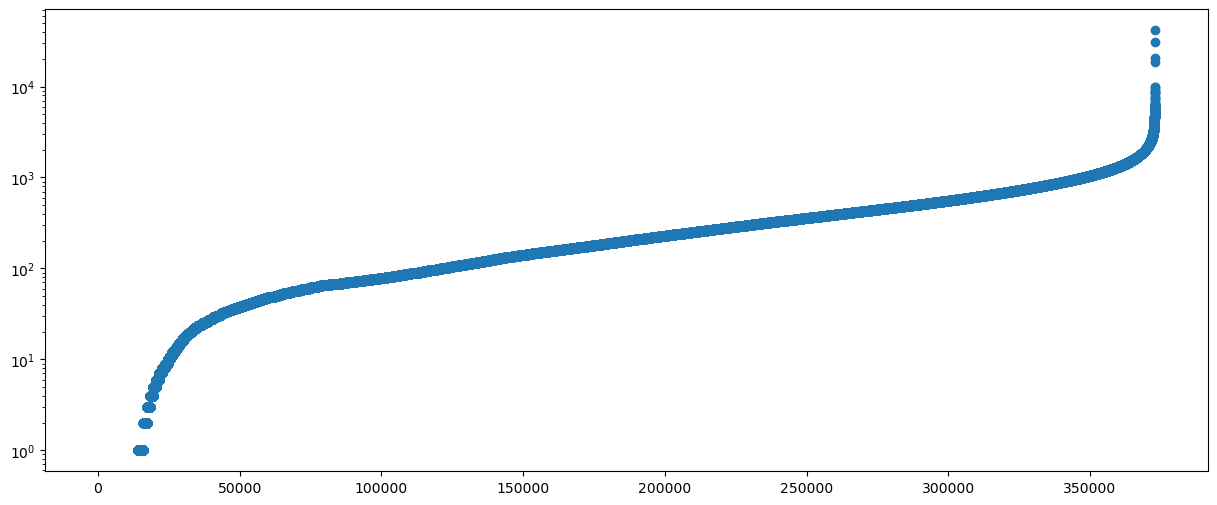

In [3]:
plt.figure(figsize=(15, 6))
plt.plot(sorted(data_demo['session_length'].values), 'o')
plt.yscale('log')
plt.show()

In [4]:
data_demo_filtred = data_demo[(data_demo['session_length']>10) & (data_demo['session_length']<10_000)]

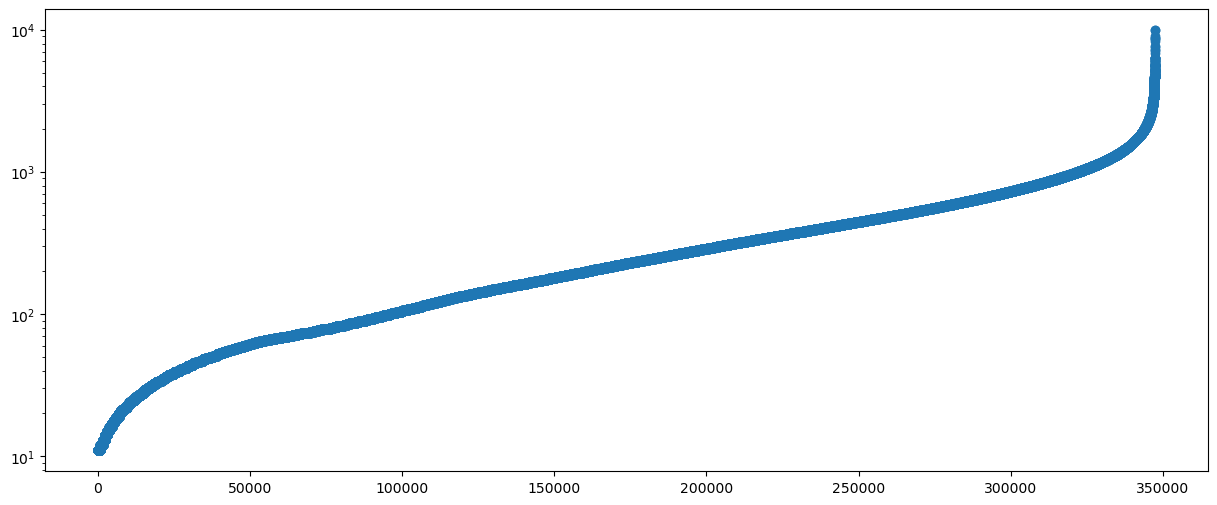

In [5]:
plt.figure(figsize=(15, 6))
plt.plot(sorted(data_demo_filtred['session_length'].values), 'o')
plt.yscale('log')
plt.show()

Nombre de doublons : 246765
  ab_cohort_name  user_count
0          xxLow       16960
1           xLow       16853
2          xHigh       16800
3       gameTune       16752
4         xxHigh       16631
5        control       16608


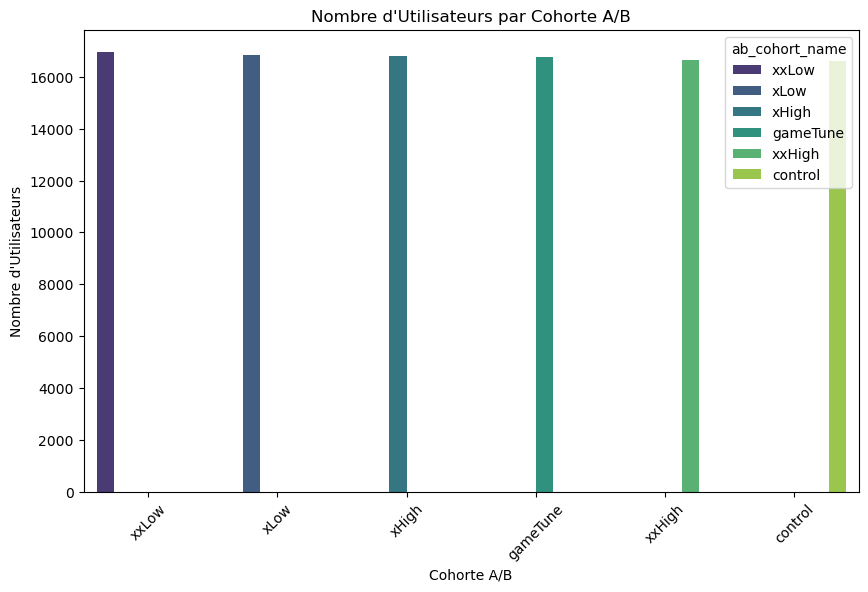

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger les données avec gestion des erreurs
# Charger les données
file_path = r'C:\Users\brice\OneDrive\Bureau\HETIC\python_projects\1er projet\Ressources\Business_Case - Business_Case.csv'   # Chemin vers votre fichier CSV
data = pd.read_csv(file_path, delimiter=',')

# Filtrer les données pour garder les sessions entre 10 et 10 000
data_demo_filtred = data[(data['session_length'] > 10) & (data['session_length'] < 10_000)]

# Vérifier le nombre de doublons avant suppression
print(f'Nombre de doublons : {data_demo_filtred.duplicated(subset="user_id").sum()}')

# Supprimer les doublons basés sur user_id
unique_users = data_demo_filtred.drop_duplicates(subset='user_id')

# Compter le nombre d'ab_cohort_name pour chaque user_id unique
cohort_counts = unique_users['ab_cohort_name'].value_counts()

# Convertir en DataFrame pour une manipulation plus facile
cohort_counts_df = cohort_counts.reset_index()
cohort_counts_df.columns = ['ab_cohort_name', 'user_count']

# Afficher le DataFrame des résultats
print(cohort_counts_df)

# Visualiser la distribution des utilisateurs par cohorte
plt.figure(figsize=(10, 6))
sns.barplot(data=cohort_counts_df, x='ab_cohort_name', y='user_count', palette='viridis',hue='ab_cohort_name')  # Choisir une palette de couleurs
plt.title('Nombre d\'Utilisateurs par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Nombre d\'Utilisateurs')
plt.xticks(rotation=45)
plt.show()

  ab_cohort_name  avg_revenue_per_session
0        control                 0.034742
1       gameTune                 0.036421
2          xHigh                 0.036997
3           xLow                 0.030695
4         xxHigh                 0.038042
5          xxLow                 0.029403


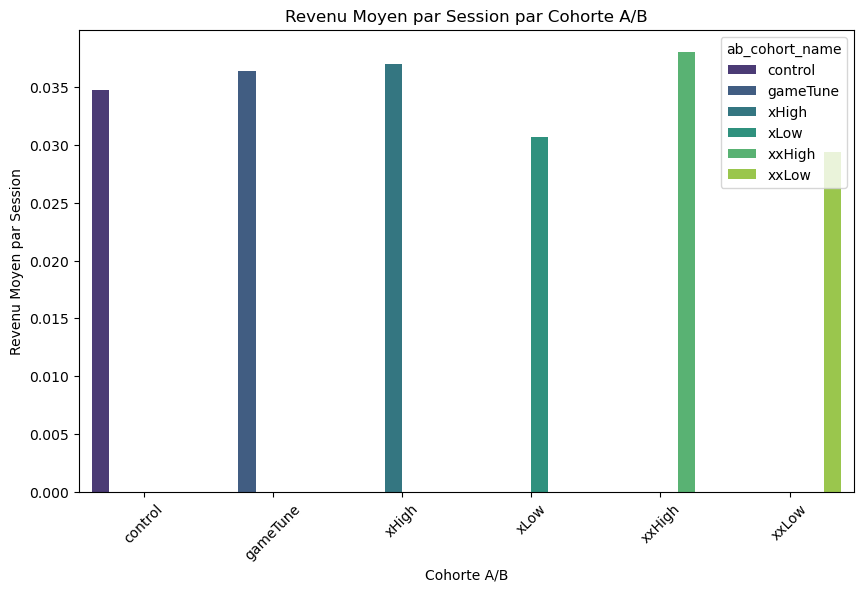

In [7]:
# Calculer le revenu moyen par session pour chaque cohorte
revenue_per_cohort = unique_users.groupby('ab_cohort_name')['publisher_revenue'].mean().reset_index()
revenue_per_cohort.columns = ['ab_cohort_name', 'avg_revenue_per_session']

# Afficher le DataFrame des résultats
print(revenue_per_cohort)

# Visualiser le revenu moyen par cohorte
plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_per_cohort, x='ab_cohort_name', y='avg_revenue_per_session', palette='viridis',hue='ab_cohort_name')
plt.title('Revenu Moyen par Session par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Revenu Moyen par Session')
plt.xticks(rotation=45)
plt.show()


  ab_cohort_name  avg_session_length  avg_sessions_per_user
0        control          294.866149               3.530949
1       gameTune          292.367299               3.403713
2          xHigh          302.929345               3.435774
3           xLow          311.230345               3.458375
4         xxHigh          288.870543               3.421803
5          xxLow          315.546875               3.466686


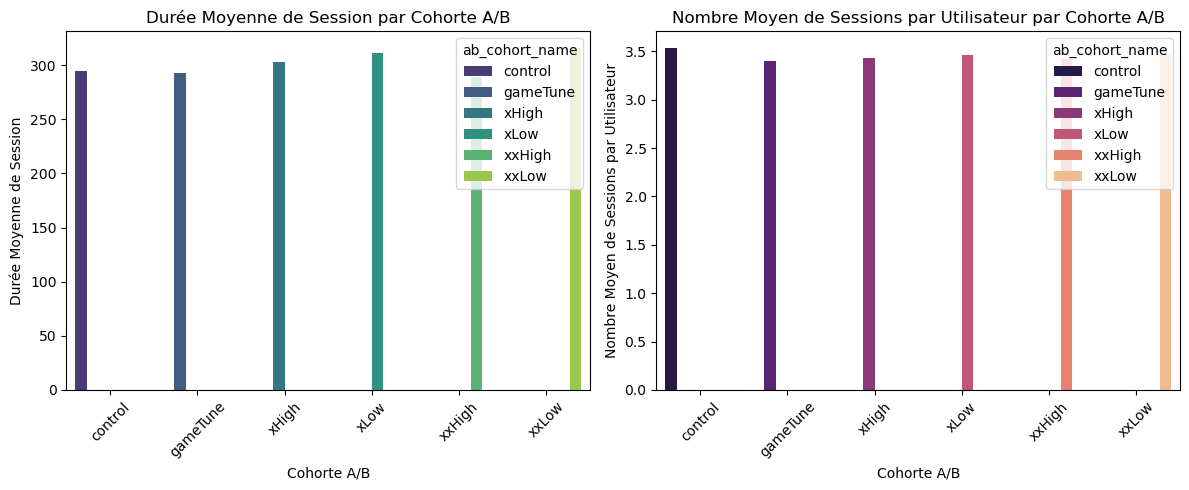

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppression des doublons basés sur user_id
unique_users = data_demo_filtred.drop_duplicates(subset='user_id')

# Calcul de la durée moyenne de session pour chaque cohorte
avg_session_duration = unique_users.groupby('ab_cohort_name')['session_length'].mean().reset_index()
avg_session_duration.columns = ['ab_cohort_name', 'avg_session_length']

# Calcul du nombre moyen de sessions par utilisateur pour chaque cohorte
sessions_per_user = data_demo_filtred.groupby('ab_cohort_name')['user_id'].nunique().reset_index()
total_sessions = data_demo_filtred.groupby('ab_cohort_name')['session_id'].count().reset_index()
sessions_per_user['avg_sessions_per_user'] = total_sessions['session_id'] / sessions_per_user['user_id']

# Fusionner les résultats pour avoir un DataFrame final
user_experience_df = avg_session_duration.merge(sessions_per_user[['ab_cohort_name', 'avg_sessions_per_user']], on='ab_cohort_name')

# Afficher le DataFrame des résultats
print(user_experience_df)

# Visualiser la durée de session moyenne par cohorte
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=user_experience_df, x='ab_cohort_name', y='avg_session_length', palette='viridis',hue='ab_cohort_name')
plt.title('Durée Moyenne de Session par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Durée Moyenne de Session')
plt.xticks(rotation=45)

# Visualiser le nombre moyen de sessions par utilisateur par cohorte
plt.subplot(1, 2, 2)
sns.barplot(data=user_experience_df, x='ab_cohort_name', y='avg_sessions_per_user', palette='magma',hue='ab_cohort_name')
plt.title('Nombre Moyen de Sessions par Utilisateur par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Nombre Moyen de Sessions par Utilisateur')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


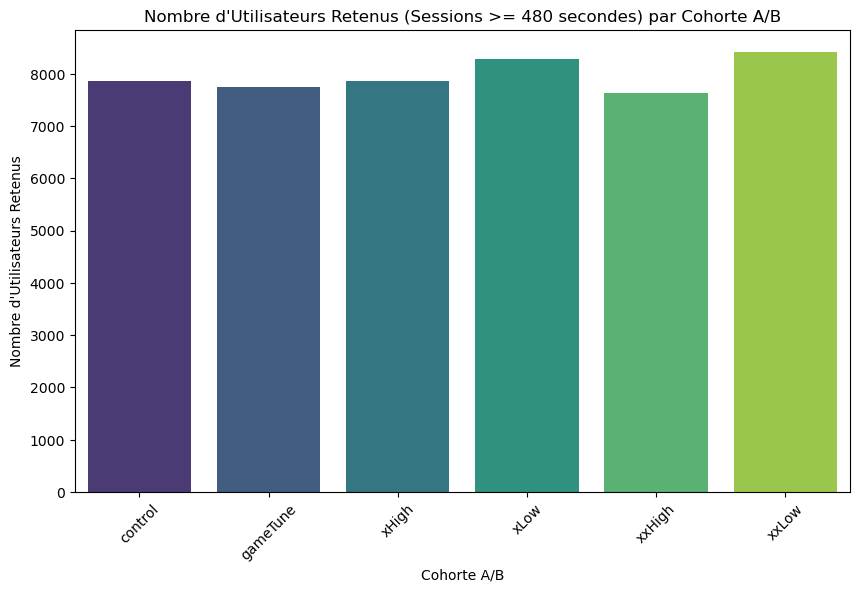

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrer les sessions avec une durée de session supérieure ou égale à 480 secondes
long_sessions = data_demo_filtred[data_demo_filtred['session_length'] >= 480]

# Compter le nombre d'utilisateurs uniques pour chaque cohorte
user_retention_per_cohort = long_sessions.groupby('ab_cohort_name')['user_id'].nunique().reset_index()
user_retention_per_cohort.columns = ['ab_cohort_name', 'user_retention_count']

# Visualiser le nombre d'utilisateurs retenus par cohorte
plt.figure(figsize=(10, 6))
sns.barplot(data=user_retention_per_cohort, x='ab_cohort_name', y='user_retention_count', palette='viridis')
plt.title('Nombre d\'Utilisateurs Retenus (Sessions >= 480 secondes) par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Nombre d\'Utilisateurs Retenus')
plt.xticks(rotation=45)
plt.show()


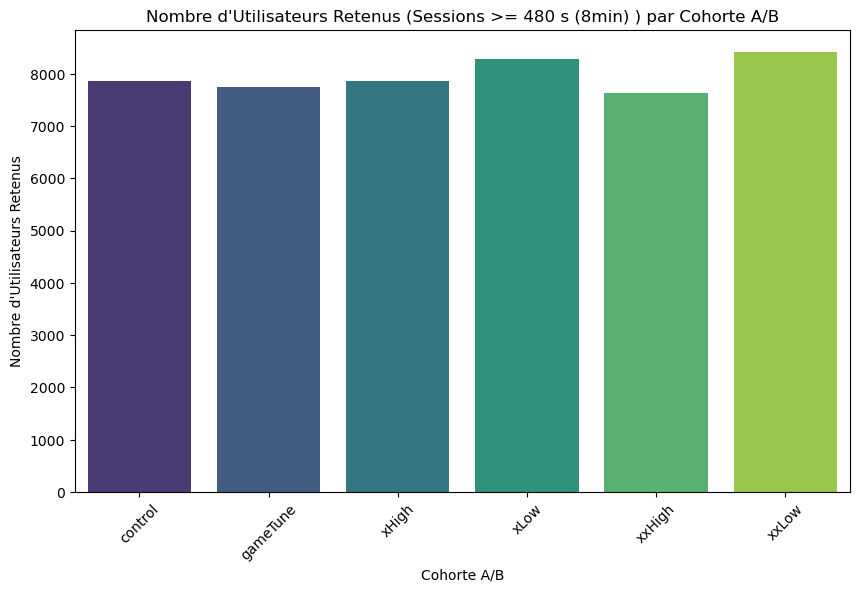

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrer les sessions avec une durée de session supérieure ou égale à 480 secondes
long_sessions = data_demo_filtred[data_demo_filtred['session_length'] >= 480]

# Compter le nombre d'utilisateurs uniques pour chaque cohorte
user_retention_per_cohort = long_sessions.groupby('ab_cohort_name')['user_id'].nunique().reset_index()
user_retention_per_cohort.columns = ['ab_cohort_name', 'user_retention_count']

# Visualiser le nombre d'utilisateurs retenus par cohorte
plt.figure(figsize=(10, 6))
sns.barplot(data=user_retention_per_cohort, x='ab_cohort_name', y='user_retention_count', palette='viridis')
plt.title('Nombre d\'Utilisateurs Retenus (Sessions >= 480 s (8min) ) par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Nombre d\'Utilisateurs Retenus')
plt.xticks(rotation=45)
plt.show()


C:\Users\brice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\brice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


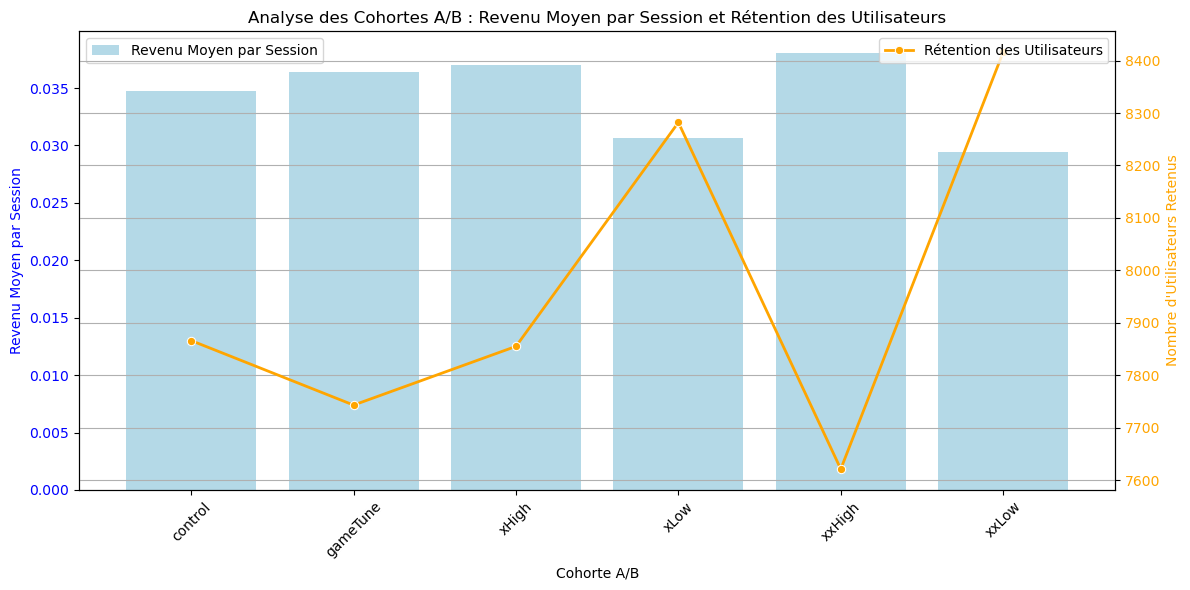

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculer le revenu moyen par session pour chaque cohorte
revenue_per_cohort = unique_users.groupby('ab_cohort_name')['publisher_revenue'].mean().reset_index()
revenue_per_cohort.columns = ['ab_cohort_name', 'avg_revenue_per_session']

# Filtrer les sessions avec une durée de session supérieure ou égale à 600 secondes
long_sessions = data_demo_filtred[data_demo_filtred['session_length'] >= 480]

# Compter le nombre d'utilisateurs uniques pour chaque cohorte
user_retention_per_cohort = long_sessions.groupby('ab_cohort_name')['user_id'].nunique().reset_index()
user_retention_per_cohort.columns = ['ab_cohort_name', 'user_retention_count']

# Fusionner les deux DataFrames sur 'ab_cohort_name'
combined_data = pd.merge(revenue_per_cohort, user_retention_per_cohort, on='ab_cohort_name')

# Visualiser le revenu moyen et la rétention par cohorte
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barres pour le revenu moyen par session
sns.barplot(data=combined_data, x='ab_cohort_name', y='avg_revenue_per_session', 
            ax=ax1, color='skyblue', label='Revenu Moyen par Session', alpha=0.7)
ax1.set_ylabel('Revenu Moyen par Session', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Créer un second axe pour le nombre d'utilisateurs retenus
ax2 = ax1.twinx()
sns.lineplot(data=combined_data, x='ab_cohort_name', y='user_retention_count', 
             color='orange', marker='o', ax=ax2, label='Rétention des Utilisateurs', linewidth=2)
ax2.set_ylabel("Nombre d'Utilisateurs Retenus", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Ajouter des titres et ajuster les éléments du graphique
plt.title('Analyse des Cohortes A/B : Revenu Moyen par Session et Rétention des Utilisateurs')
ax1.set_xlabel('Cohorte A/B')
ax1.set_xticks(range(len(combined_data['ab_cohort_name'])))  # Définir les positions fixes
ax1.set_xticklabels(combined_data['ab_cohort_name'], rotation=45)  # Appliquer les étiquettes
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.grid(axis='y')
plt.tight_layout()
plt.show()



In [14]:
import pandas as pd

# Charger le jeu de données
file_path = r'C:\Users\brice\OneDrive\Bureau\HETIC\python_projects\1er projet\Ressources\Business_Case - Business_Case.csv'
data_demo = pd.read_csv(file_path)
data_demo_filtred = data_demo[(data_demo['session_length']>10) & (data_demo['session_length']<10_000)]

# Ajout de la colonne 'profitable_loyalty_score' dans le DataFrame d'origine
data_demo_filtred['profitable_loyalty_score'] = data_demo_filtred['publisher_revenue'] * data_demo_filtred['session_length'] * (data_demo_filtred['session_length'] >= 480)

# Créer un nouveau DataFrame avec 'ab_cohort_name' et 'profitable_loyalty_score'
new_dataframe = data_demo_filtred[['ab_cohort_name', 'profitable_loyalty_score']].copy()

# Vérifier les données du nouveau DataFrame
print(new_dataframe.head())



  ab_cohort_name  profitable_loyalty_score
0       gameTune                  0.000000
1       gameTune                  0.000000
2       gameTune                  0.000000
3         xxHigh                 28.701152
4       gameTune                  0.000000


C:\Users\brice\AppData\Local\Temp\ipykernel_11596\10695545.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_demo_filtred['profitable_loyalty_score'] = data_demo_filtred['publisher_revenue'] * data_demo_filtred['session_length'] * (data_demo_filtred['session_length'] >= 480)


  ab_cohort_name  profitable_loyalty_score
0       gameTune                  0.000000
1       gameTune                  0.000000
2       gameTune                  0.000000
3         xxHigh                 28.701152
4       gameTune                  0.000000
Test de normalité (Kolmogorov-Smirnov) et Q-Q plots :

Campagne 'gameTune': Stat=0.394, p-value=0.000


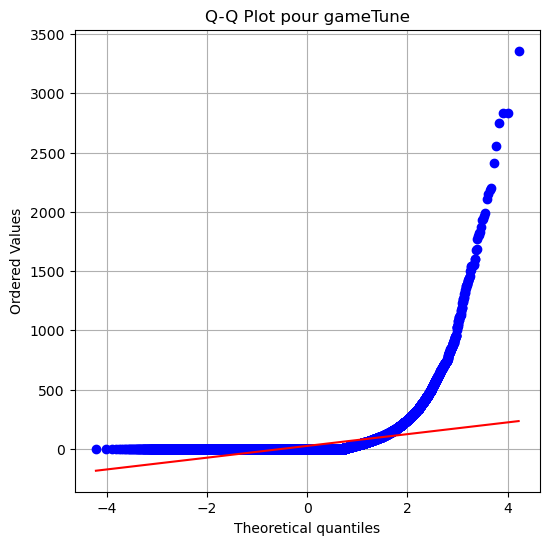

Campagne 'xxHigh': Stat=0.405, p-value=0.000


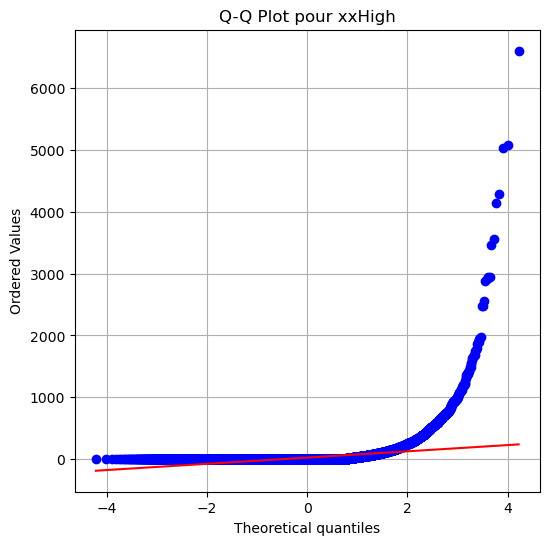

Campagne 'xxLow': Stat=0.413, p-value=0.000


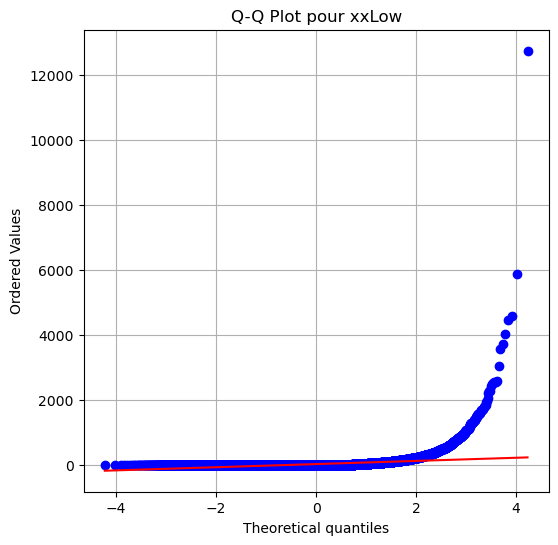

Campagne 'xHigh': Stat=0.400, p-value=0.000


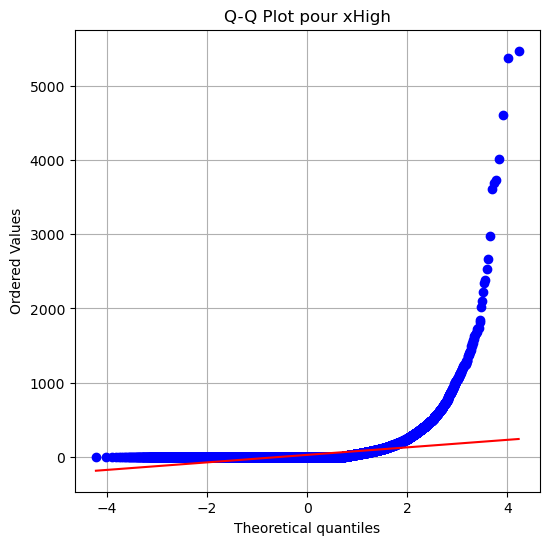

Campagne 'xLow': Stat=0.394, p-value=0.000


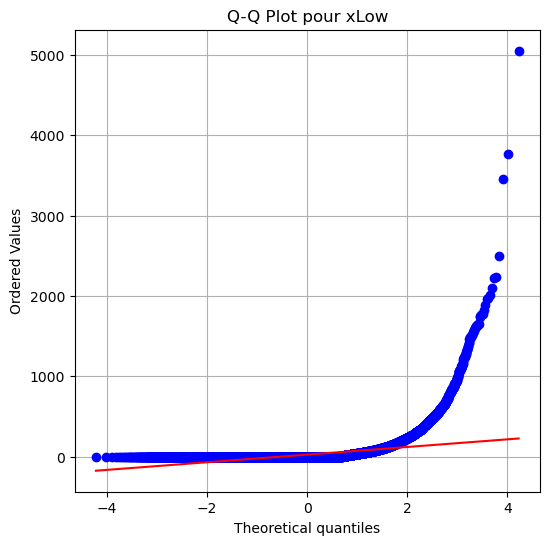

Campagne 'control': Stat=0.396, p-value=0.000


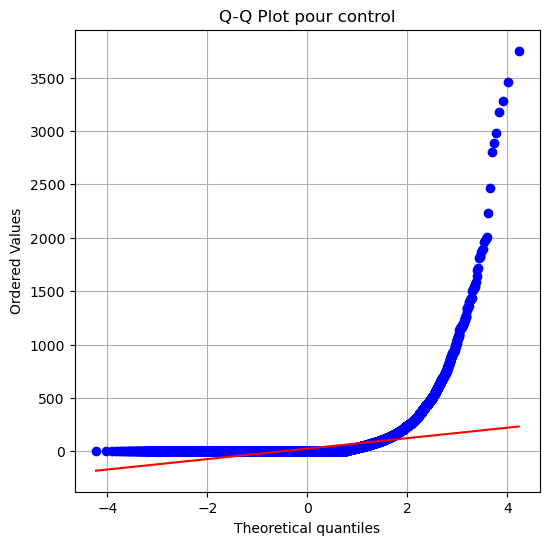

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest, probplot

# Chargement du DataFrame (new_dataframe déjà existant ici)
# Vérifiez que new_dataframe contient bien les colonnes nécessaires
print(new_dataframe.head())

# Liste des campagnes, incluant 'control' et les autres
campagnes = new_dataframe['ab_cohort_name'].unique()

# Vérification de la Normalité pour chaque campagne
print("Test de normalité (Kolmogorov-Smirnov) et Q-Q plots :\n")
for campagne in campagnes:
    scores = new_dataframe[new_dataframe['ab_cohort_name'] == campagne]['profitable_loyalty_score'].dropna()
    
    # Test de Kolmogorov-Smirnov pour la normalité
    stat, p_value = kstest(scores, 'norm', args=(scores.mean(), scores.std()))
    print(f"Campagne '{campagne}': Stat={stat:.3f}, p-value={p_value:.3f}")
    
    # Affichage du Q-Q plot
    plt.figure(figsize=(6, 6))
    probplot(scores, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot pour {campagne}")
    plt.grid()
    plt.show()


In [19]:
from scipy.stats import kruskal, mannwhitneyu

# Test de Kruskal-Wallis pour comparer toutes les campagnes
groupes = [new_dataframe[new_dataframe['ab_cohort_name'] == campagne]['profitable_loyalty_score'].dropna() for campagne in campagnes]
stat, p_value = kruskal(*groupes)
print(f"\nTest de Kruskal-Wallis: Stat={stat:.3f}, p-value={p_value:.20f}")

# Si le test de Kruskal-Wallis indique une différence significative, on passe aux tests post hoc
if p_value < 0.05:
    control_scores = new_dataframe[new_dataframe['ab_cohort_name'] == 'control']['profitable_loyalty_score'].dropna()
    print("\nComparaison post hoc avec le groupe 'control' :\n")

    for campagne in campagnes:
        if campagne != 'control':  # Exclure 'control' pour la comparaison
            campagne_scores = new_dataframe[new_dataframe['ab_cohort_name'] == campagne]['profitable_loyalty_score'].dropna()
            stat, p_value = mannwhitneyu(campagne_scores, control_scores, alternative='two-sided')
            print(f"Comparaison '{campagne}' vs 'control': Stat={stat:.3f}, p-value={p_value:.9f}")
            
            # Interprétation des résultats pour chaque campagne
            if p_value < 0.05:
                print(f"Différence statistiquement significative entre '{campagne}' et 'control'.\n")
            else:
                print(f"Aucune différence significative entre '{campagne}' et 'control'.\n")
else:
    print("Aucune différence significative entre les campagnes d'après le test de Kruskal-Wallis.")



Test de Kruskal-Wallis: Stat=78.893, p-value=0.00000000000000143031

Comparaison post hoc avec le groupe 'control' :

Comparaison 'gameTune' vs 'control': Stat=1667428426.000, p-value=0.298058361
Aucune différence significative entre 'gameTune' et 'control'.

Comparaison 'xxHigh' vs 'control': Stat=1659414911.500, p-value=0.030252021
Différence statistiquement significative entre 'xxHigh' et 'control'.

Comparaison 'xxLow' vs 'control': Stat=1744636952.500, p-value=0.000002679
Différence statistiquement significative entre 'xxLow' et 'control'.

Comparaison 'xHigh' vs 'control': Stat=1693493192.500, p-value=0.806119355
Aucune différence significative entre 'xHigh' et 'control'.

Comparaison 'xLow' vs 'control': Stat=1727187326.000, p-value=0.000030594
Différence statistiquement significative entre 'xLow' et 'control'.

